## Setup

In [1]:
%load_ext autoreload
%autoreload 2

# To ensure reproducibility
seed = 7214

Set up the working environment:

In [2]:
# Import path libraries
import os
import sys
import pathlib

# Modify this flag variable to control whether the irrelevant features are 
# filtered or not
enable_filter = True

# Define paths
project_path = pathlib.Path("/workspaces/TFM").resolve()
data_path = project_path / "data" / "clean" / "whole_clinical_data.parquet"

if enable_filter:
    results_path = project_path / "results" / "models" / "whole_clinical_data_filtered"
else:
    results_path = project_path / "results" / "models" / "whole_clinical_data"

# Add the project path to sys.path if it's not already there
if str(project_path) not in sys.path:
    sys.path.append(str(project_path))

print(f"Loading data from: {data_path}")
print(f"Saving results to: {results_path}")

Loading data from: /workspaces/TFM/data/clean/whole_clinical_data.parquet
Saving results to: /workspaces/TFM/results/models/whole_clinical_data_filtered


Load libraries:

In [52]:
# DATA WRANGLING, STATISTICS
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pandas.api.types import CategoricalDtype
from scipy.stats import uniform, randint, loguniform

# DATA PREPROCESSING
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold

# MODELS
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, 
                            ExtraTreesClassifier, 
                            AdaBoostClassifier, 
                            GradientBoostingClassifier)
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (roc_curve, 
                            precision_recall_curve, 
                            roc_auc_score, 
                            average_precision_score)

# CUSTOM MODULES
from src.models import *

## Data

Load hatch score results from the previous analysis:

In [4]:
# Define path
hatch_scores_path = project_path / "results" / "models" / "hatch_data" / "hatch_metrics.csv"

# Load hatch score results
hatch_scores = pd.read_csv(hatch_scores_path)

hatch_scores

,ROC-AUC,PR-AUC
0,0.534699,0.4174


Extract the scores values:

In [5]:
roc_auc_hatch = hatch_scores["ROC-AUC"].values[0].astype(float)
pr_auc_hatch = hatch_scores["PR-AUC"].values[0].astype(float)

Load clinical data:

In [6]:
# Load dataset
df = pd.read_parquet(data_path)

# Check general structure
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Data columns (total 29 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   sex                   720 non-null    object 
 1   age                   720 non-null    float64
 2   smoking_status        720 non-null    object 
 3   code                  720 non-null    float64
 4   center                720 non-null    object 
 5   intervention          720 non-null    object 
 6   BMI                   720 non-null    float64
 7   Met                   720 non-null    float64
 8   glucose               690 non-null    float64
 9   type1_diabetes        720 non-null    object 
 10  type2_diabetes        720 non-null    object 
 11  HDL                   646 non-null    float64
 12  triglicerides         650 non-null    float64
 13  hypercholesterolemia  720 non-null    object 
 14  OSA                   720 non-null    object 
 15  renal_insuf           720 non-null

Let's transform the categorical features `object` data type into `category` and check their values:

In [7]:
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].astype('category')
    print(f"Categories of column '{col}': {df[col].cat.categories.tolist()}")

Categories of column 'sex': ['female', 'male']
Categories of column 'smoking_status': ['current', 'former', 'never']
Categories of column 'center': ['Alicante', 'Granada', 'Madrid', 'Pamplona']
Categories of column 'intervention': ['control', 'intervention']
Categories of column 'type1_diabetes': ['no', 'yes']
Categories of column 'type2_diabetes': ['no', 'yes']
Categories of column 'hypercholesterolemia': ['no', 'yes']
Categories of column 'OSA': ['no', 'yes']
Categories of column 'renal_insuf': ['no', 'yes']
Categories of column 'hypertension': ['no', 'yes']
Categories of column 'COPD': ['no', 'yes']
Categories of column 'stroke': ['no', 'yes']
Categories of column 'cardiomyopathy': ['no', 'yes']
Categories of column 'antirrythmic_meds': ['no', 'yes']
Categories of column 'LA_enlargment': ['mild', 'moderate', 'normal', 'severe']
Categories of column 'LVEF': ['moderately abnormal', 'normal', 'severely abnormal', 'slightly abnormal']
Categories of column 'AF_type': ['paroxysmal', 'pers

Since there are some categorical features where their categories are randomly arranged, they need to be manually rearranged in order to encode them properly:

In [8]:
# Rearrange categories manually
df['sex'] = df['sex'].astype(CategoricalDtype(categories=["male", "female"], ordered=True))
df['smoking_status'] = df['smoking_status'].astype(CategoricalDtype(categories=["never", "former", "current"], ordered=True))
df['LA_enlargment'] = df['LA_enlargment'].astype(CategoricalDtype(categories=["normal", "mild", "moderate", "severe"], ordered=True))
df['LVEF'] = df['LVEF'].astype(CategoricalDtype(categories=["normal", "slightly abnormal", "moderately abnormal", "severely abnormal"], ordered=True))


Separate the features from the target class:

In [9]:
# Drop the target class and the non-informative features
X = df.drop([
    "code",
    "center",
    "AF_recurrence", 
    "hatch_score"
            ], axis=1)

# Select the target class and encode it manually
y = df["AF_recurrence"].map({"no":0, "yes":1})

Divide data set into train ($80 \%$) and test ($20 \%$) sets :

In [10]:
# Divide into train and test set
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    shuffle=True,
    stratify=y,
    )

## Training and optimization

`n_trials` per model with stratified `n_cv`-fold cross validation:

In [11]:
# Number of trials for hyperparameter search
n_trials = 200

# Number of splits
n_cv = 5

# Cross-validation strategy
my_cv = StratifiedKFold(n_splits=n_cv, shuffle=True, random_state=42)

Define metrics to evaluate:

In [12]:
# Set up the scoring dictionary for cross-validation
scoring_dict = {
        'ROC-AUC': 'roc_auc',
        'PR-AUC': 'average_precision'
    }

objective_metric = "PR-AUC"

#### Logistic Regression (Elastic Net)

Define the parameter distributions and set up the pipeline:

In [13]:
# Get the preprocessor
preprocessor_EN = get_full_preprocessor(X_train, seed=seed)

# Build the pipeline
pipe_EN = Pipeline(steps=[
    ('preprocessor', preprocessor_EN),
    ('clf', LogisticRegression(random_state=seed, solver='saga', max_iter=10000))
])

# Hyperparameters search space
params_EN = {
    'clf__l1_ratio': uniform(0, 1),
    'clf__C': loguniform(1e-4, 1e3)
    }

Train and optimize the model:

In [14]:
(
optimized_EN, 
cv_results_EN,
fpr_EN, tpr_EN,
precs_EN, recs_EN
) = optimize_model_random_search(
    pipeline=pipe_EN, 
    param_distributions=params_EN, 
    X_train=X_train, y_train=y_train, 
    X_test=X_test, y_test=y_test, 
    metrics_dict=scoring_dict, 
    aim=scoring_dict[objective_metric],
    cv=my_cv,
    n_iter=n_trials,
    seed=seed
    )

Starting randomized hyperparameter optimization...
Fitting 5 folds for each of 200 candidates, totalling 1000 fits
Evaluating on the training set...
Evaluating on the test set...


Save the optimized model and check the hyperparameters:

In [15]:
save_model(fitted_pipeline=optimized_EN, output_dir=results_path, identifier="EN")

,Hyperparameter,Optimal Value
1,C,0.115161
2,dual,False
3,fit_intercept,True
4,intercept_scaling,1
5,l1_ratio,0.946275
6,max_iter,10000
7,penalty,deprecated
8,random_state,7214
9,solver,saga
10,tol,0.0001


Check the overfitting:

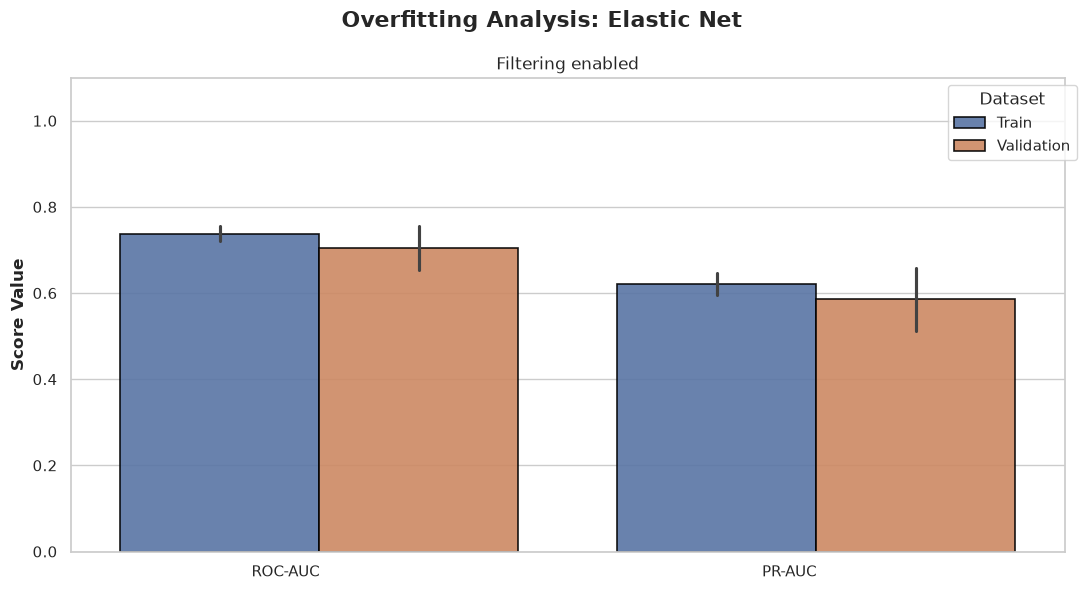

In [16]:
plot_overfitting_bars(df_cv_results=cv_results_EN, 
                    title="Elastic Net", 
                    output_dir=results_path, 
                    identifier="EN",
                    filtering=enable_filter)

Take a look at the relevant columns:

In [17]:
relevant_cols, irrelevant_cols = get_relevant_features(optimized_EN)

print("relevant features: ", relevant_cols)
print("\n")
print("irrelevant features: ", irrelevant_cols)

relevant features:  ['ERAF', 'AF_type', 'AF_ablation_time', 'sex', 'stroke', 'previous_ablation', 'hypertension', 'intervention', 'Met', 'age', 'cardiomyopathy', 'OSA', 'antirrythmic_meds']


irrelevant features:  ['BMI', 'glucose', 'HDL', 'triglicerides', 'smoking_status', 'type1_diabetes', 'type2_diabetes', 'hypercholesterolemia', 'renal_insuf', 'COPD', 'LA_enlargment', 'LVEF']


Drop irrelevant features from the data set:

In [18]:
if enable_filter:
    X_train_filtered = X_train.drop(columns=irrelevant_cols)
    X_test_filtered = X_test.drop(columns=irrelevant_cols)
else:
    X_train_filtered = X_train
    X_test_filtered = X_test

#### Support Vector Machine

Define the parameter distributions and set up the pipeline:

In [19]:
# Get preprocessor
preprocessor_SVM = get_full_preprocessor(X_train_filtered, seed=seed)

# Build the pipeline
pipe_SVM = Pipeline(steps=[
    ('preprocessor', preprocessor_SVM),
    ('clf', SVC(random_state=seed, max_iter=100000))
])

# Hyperparameters search space
params_dist_SVM = {
    'clf__C': loguniform(1e-5, 1e3),
    'clf__kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
    'clf__gamma': ['scale', 'auto'] + list(np.logspace(-4, 1, 50)),
    'clf__degree': randint(2, 4),
    'clf__class_weight': [None, 'balanced']
}

Train and optimize the model:

In [20]:
(
optimized_SVM, 
cv_results_SVM,
fpr_SVM, tpr_SVM,
precs_SVM, recs_SVM
) = optimize_model_random_search(
    pipeline=pipe_SVM, 
    param_distributions=params_dist_SVM, 
    X_train=X_train_filtered, y_train=y_train, 
    X_test=X_test_filtered, y_test=y_test, 
    metrics_dict=scoring_dict, 
    cv=my_cv,
    n_iter=n_trials,
    seed=seed
    )

Starting randomized hyperparameter optimization...
Fitting 5 folds for each of 200 candidates, totalling 1000 fits


/opt/conda/envs/tfm_python/lib/python3.11/site-packages/sklearn/svm/_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=100000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/conda/envs/tfm_python/lib/python3.11/site-packages/sklearn/svm/_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=100000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/conda/envs/tfm_python/lib/python3.11/site-packages/sklearn/svm/_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=100000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/conda/envs/tfm_python/lib/python3.11/site-packages/sklearn/svm/_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=100000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/conda/envs/tfm_python/lib/python3.11/site-packages/sklearn/

Evaluating on the training set...
Evaluating on the test set...


Save the optimized model and check the hyperparameters:

In [21]:
save_model(fitted_pipeline=optimized_SVM, output_dir=results_path, identifier="SVM")

,Hyperparameter,Optimal Value
1,C,1.519645
2,break_ties,False
3,cache_size,200
4,coef0,0.0
5,decision_function_shape,ovr
6,degree,3
7,gamma,0.003393
8,kernel,linear
9,max_iter,100000
10,probability,deprecated


Check the overfitting:

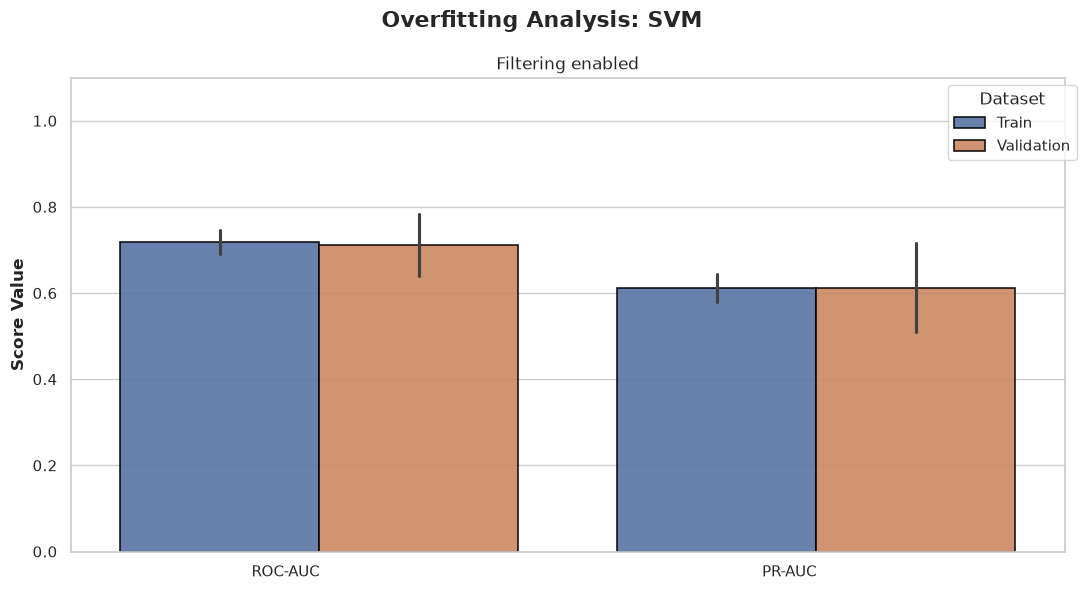

In [22]:
plot_overfitting_bars(df_cv_results=cv_results_SVM, 
                    title="SVM", 
                    output_dir=results_path, 
                    identifier="SVM",
                    filtering=enable_filter)

#### Decision Tree

Define the parameter distributions and set up the pipeline:

In [23]:
# Get the preprocessor
preprocessor_DT = get_trees_preprocessor(X_train_filtered, seed=seed)

# Build the pipeline
pipe_DT = Pipeline(steps=[
    ('preprocessor', preprocessor_DT),
    ('clf', DecisionTreeClassifier(random_state=seed))
])

# Hyperparameters search space
params_dist_DT = {
    'clf__max_depth': randint(2, 33),
    'clf__min_samples_split': randint(2, 21),
    'clf__min_samples_leaf': randint(1, 21),
    'clf__criterion': ['gini', 'entropy'],
}


Train and optimize the model:

In [24]:
(
optimized_DT, 
cv_results_DT,
fpr_DT, tpr_DT,
precs_DT, recs_DT
) = optimize_model_random_search(
    pipeline=pipe_DT, 
    param_distributions=params_dist_DT, 
    X_train=X_train_filtered, y_train=y_train, 
    X_test=X_test_filtered, y_test=y_test, 
    metrics_dict=scoring_dict, 
    cv=my_cv,
    n_iter=n_trials,
    seed=seed
    )

Starting randomized hyperparameter optimization...
Fitting 5 folds for each of 200 candidates, totalling 1000 fits
Evaluating on the training set...
Evaluating on the test set...


Save the optimized model and check the hyperparameters:

In [25]:
save_model(fitted_pipeline=optimized_DT, output_dir=results_path, identifier="DT")

,Hyperparameter,Optimal Value
1,ccp_alpha,0.0
2,criterion,gini
3,max_depth,5
4,min_impurity_decrease,0.0
5,min_samples_leaf,5
6,min_samples_split,9
7,min_weight_fraction_leaf,0.0
8,random_state,7214
9,splitter,best


Check the overfitting:

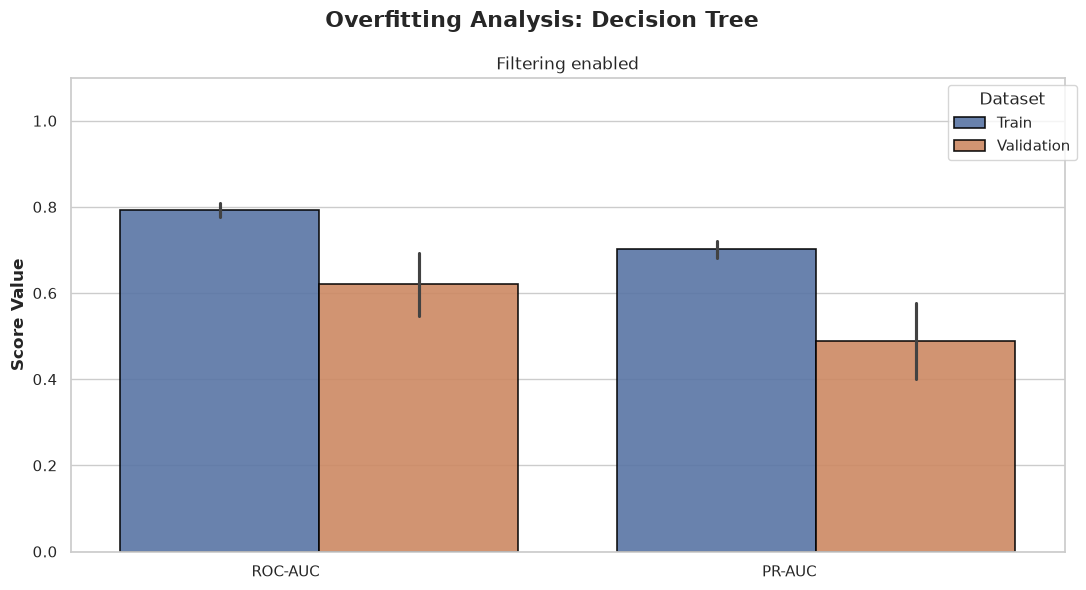

In [26]:
plot_overfitting_bars(df_cv_results=cv_results_DT, 
                    title="Decision Tree", 
                    output_dir=results_path, 
                    identifier="DT",
                    filtering=enable_filter)

#### Random Forest

Define the parameter distributions and set up the pipeline:

In [27]:
# Get the preprocessor
preprocessor_RF = get_trees_preprocessor(X_train_filtered, seed=seed)

# Build the pipeline
pipe_RF = Pipeline(steps=[
    ('preprocessor', preprocessor_RF),
    ('clf', RandomForestClassifier(random_state=seed))
])

# Hyperparameters search space
params_dist_RF = {
    # Decision trees hyperparameters
    'clf__max_depth': [None] + list(range(2, 20)),
    'clf__max_features': ['sqrt', 'log2', None] + list(np.arange(0.2, 0.9, 0.1)),
    'clf__min_samples_split': randint(2, 21),
    'clf__min_samples_leaf': randint(1, 21),
    'clf__criterion': ['gini', 'entropy'],
    
    # Ensemble bagging hyperparameters
    'clf__n_estimators': randint(50, 501),
    'clf__class_weight': [None, 'balanced', 'balanced_subsample']
}

Train and optimize the model:

In [28]:
(
optimized_RF, 
cv_results_RF,
fpr_RF, tpr_RF,
precs_RF, recs_RF
) = optimize_model_random_search(
    pipeline=pipe_RF, 
    param_distributions=params_dist_RF, 
    X_train=X_train_filtered, y_train=y_train, 
    X_test=X_test_filtered, y_test=y_test, 
    metrics_dict=scoring_dict, 
    cv=my_cv,
    n_iter=n_trials,
    seed=seed
    )

Starting randomized hyperparameter optimization...
Fitting 5 folds for each of 200 candidates, totalling 1000 fits
Evaluating on the training set...
Evaluating on the test set...


Save the optimized model and check the hyperparameters:

In [29]:
save_model(fitted_pipeline=optimized_RF, output_dir=results_path, identifier="RF")

,Hyperparameter,Optimal Value
1,bootstrap,True
2,ccp_alpha,0.0
3,criterion,entropy
4,max_depth,2
5,max_features,0.3
6,min_impurity_decrease,0.0
7,min_samples_leaf,2
8,min_samples_split,12
9,min_weight_fraction_leaf,0.0
10,n_estimators,296


Check the overfitting:

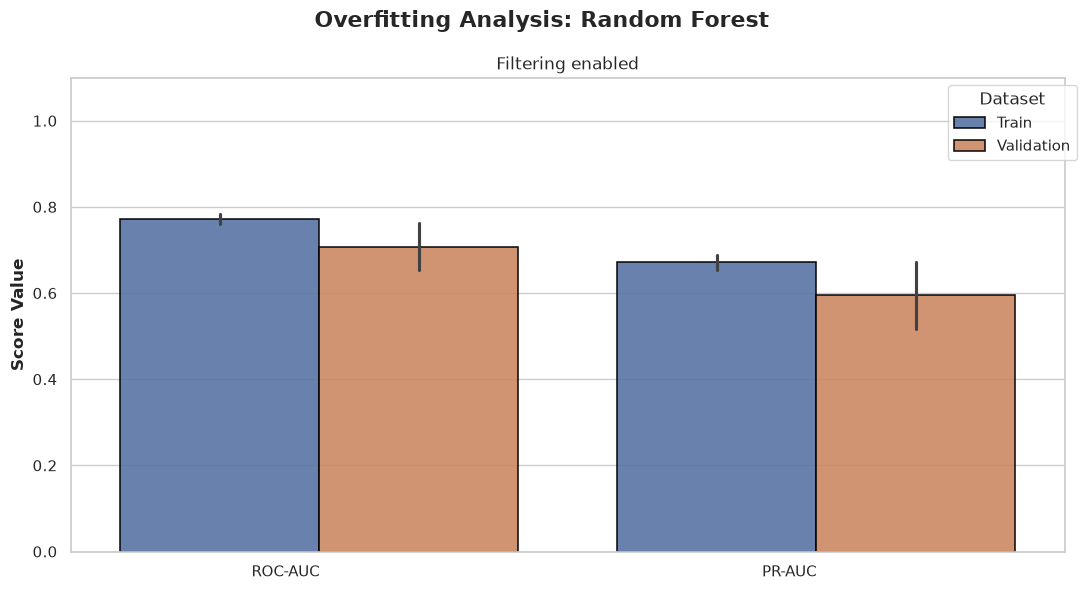

In [30]:
plot_overfitting_bars(df_cv_results=cv_results_RF, 
                    title="Random Forest", 
                    output_dir=results_path, 
                    identifier="RF",
                    filtering=enable_filter)

#### Extra Trees


Define the parameter distributions and set up the pipeline:


In [31]:
# Get the preprocessor
preprocessor_ET = get_trees_preprocessor(X_train_filtered, seed=seed)

# Build the pipeline
pipe_ET = Pipeline(steps=[
    ('preprocessor', preprocessor_ET),
    ('clf', ExtraTreesClassifier(random_state=seed))
])

# Hyperparameters search space
params_dist_ET = {
    # Decision trees hyperparameters
    'clf__max_depth': [None] + list(range(2, 20)),
    'clf__max_features': ['sqrt', 'log2', None] + list(np.arange(0.2, 0.9, 0.1)),
    'clf__min_samples_split': randint(2, 21),
    'clf__min_samples_leaf': randint(1, 21),
    'clf__criterion': ['gini', 'entropy'],
    
    # Ensemble bagging hyperparameters
    'clf__n_estimators': randint(50, 501),
    'clf__class_weight': [None, 'balanced', 'balanced_subsample']
}

Train and optimize the model:


In [32]:
(
optimized_ET, 
cv_results_ET,
fpr_ET, tpr_ET,
precs_ET, recs_ET
) = optimize_model_random_search(
    pipeline=pipe_ET, 
    param_distributions=params_dist_ET, 
    X_train=X_train_filtered, y_train=y_train, 
    X_test=X_test_filtered, y_test=y_test, 
    metrics_dict=scoring_dict, 
    cv=my_cv,
    n_iter=n_trials,
    seed=seed
    )

Starting randomized hyperparameter optimization...
Fitting 5 folds for each of 200 candidates, totalling 1000 fits
Evaluating on the training set...
Evaluating on the test set...


Save the optimized model and check the hyperparameters:


In [33]:
save_model(fitted_pipeline=optimized_ET, output_dir=results_path, identifier="ET")


,Hyperparameter,Optimal Value
1,bootstrap,False
2,ccp_alpha,0.0
3,class_weight,balanced
4,criterion,entropy
5,max_depth,5
6,max_features,sqrt
7,min_impurity_decrease,0.0
8,min_samples_leaf,1
9,min_samples_split,8
10,min_weight_fraction_leaf,0.0


Check the overfitting:


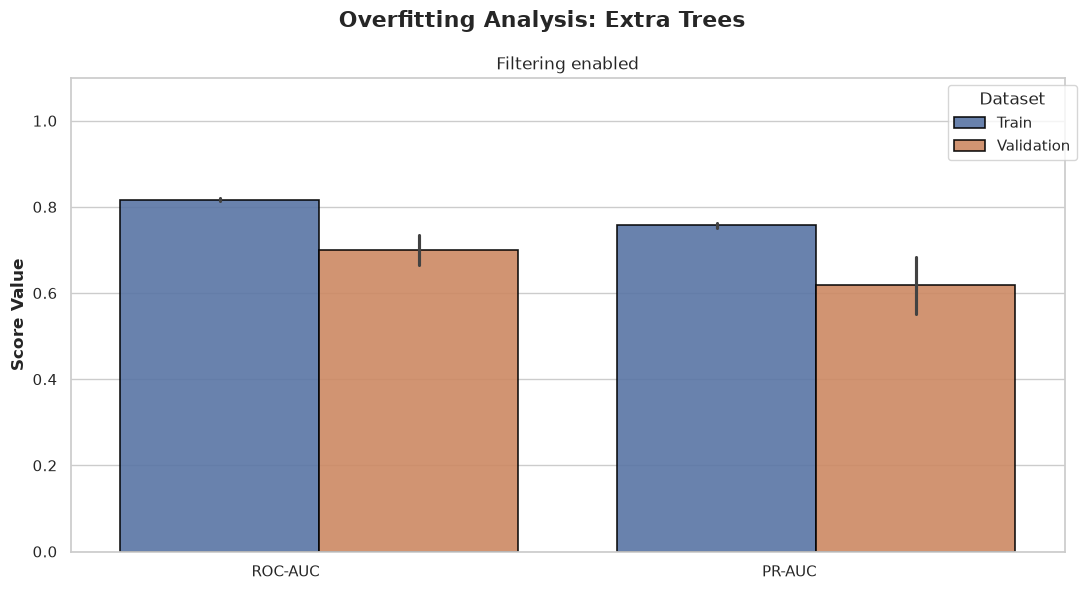

In [34]:
plot_overfitting_bars(df_cv_results=cv_results_ET, 
                    title="Extra Trees", 
                    output_dir=results_path, 
                    identifier="ET",
                    filtering=enable_filter)


#### Adaptative Boosting

Define the parameter distributions and set up the pipeline:

In [35]:
# Get the preprocessor
preprocessor_AB = get_trees_preprocessor(X_train_filtered, seed=seed)

# Build the pipeline
pipe_AB = Pipeline(steps=[
    ('preprocessor', preprocessor_AB),
    ('clf', AdaBoostClassifier(random_state=seed, 
                            estimator=DecisionTreeClassifier(random_state=seed)))
])

# Hyperparameters search space
params_dist_AB = {
    # Decision trees hyperparameters
    'clf__estimator__max_depth': randint(1, 4),
    'clf__estimator__max_features': ['sqrt', 'log2', None],
    'clf__estimator__min_samples_split': randint(2, 21),
    'clf__estimator__criterion': ['gini', 'entropy'],
    
    # Ensemble boosting hyperparameters
    'clf__n_estimators': randint(50, 501),
    'clf__learning_rate': loguniform(0.001, 1.0) 
}


Train and optimize the model:

In [36]:
(
optimized_AB, 
cv_results_AB,
fpr_AB, tpr_AB,
precs_AB, recs_AB
) = optimize_model_random_search(
    pipeline=pipe_AB, 
    param_distributions=params_dist_AB, 
    X_train=X_train_filtered, y_train=y_train, 
    X_test=X_test_filtered, y_test=y_test, 
    metrics_dict=scoring_dict, 
    cv=my_cv,
    n_iter=n_trials,
    seed=seed
    )

Starting randomized hyperparameter optimization...
Fitting 5 folds for each of 200 candidates, totalling 1000 fits
Evaluating on the training set...
Evaluating on the test set...


Save the optimized model and check the hyperparameters:

In [37]:
save_model(fitted_pipeline=optimized_AB, output_dir=results_path, identifier="AB")

,Hyperparameter,Optimal Value
1,estimator__ccp_alpha,0.0
2,estimator__criterion,gini
3,estimator__max_depth,1
4,estimator__max_features,sqrt
5,estimator__min_impurity_decrease,0.0
6,estimator__min_samples_leaf,1
7,estimator__min_samples_split,3
8,estimator__min_weight_fraction_leaf,0.0
9,estimator__random_state,7214
10,estimator__splitter,best


Check the overfitting:

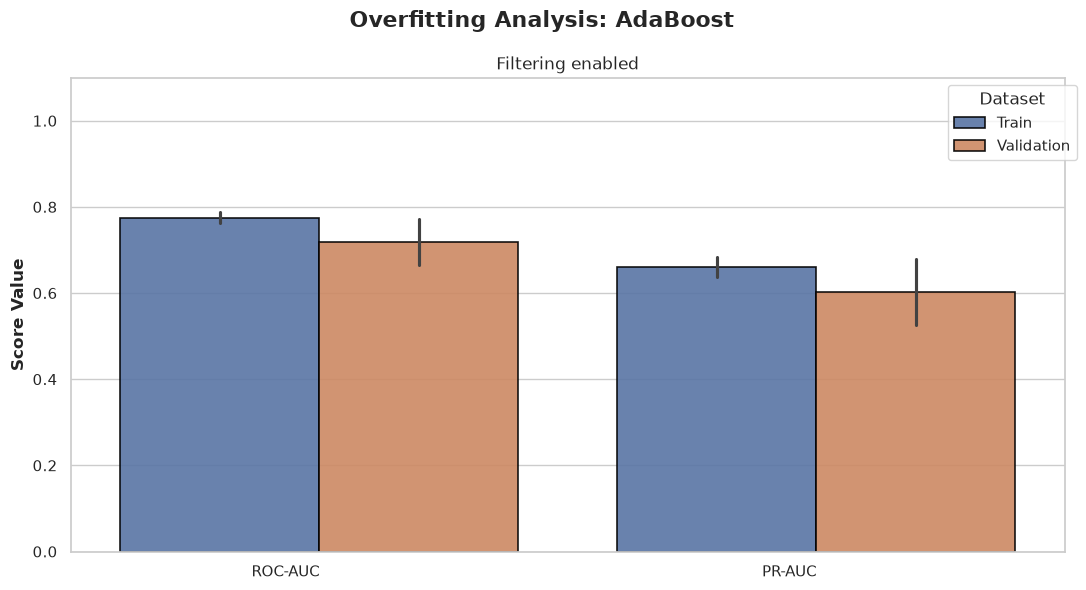

In [38]:
plot_overfitting_bars(df_cv_results=cv_results_AB, 
                    title="AdaBoost", 
                    output_dir=results_path, 
                    identifier="AB",
                    filtering=enable_filter)

#### Gradient Boosting

Define the parameter distributions and set up the pipeline:

In [39]:
# Get the preprocessor
preprocessor_GB = get_trees_preprocessor(X_train_filtered, seed=seed)

# Build the pipeline
pipe_GB = Pipeline(steps=[
    ('preprocessor', preprocessor_GB),
    ('clf', GradientBoostingClassifier(random_state=seed ))
])

# Hyperparameters search space
params_dist_GB = {
    # Decision trees hyperparameters
    'clf__max_depth': randint(2, 6),
    'clf__max_features': ['sqrt', 'log2', None] + list(np.arange(0.2, 0.9, 0.1)),
    'clf__min_samples_split': randint(2, 21),
    'clf__min_samples_leaf': randint(1, 21),
    
    # Ensemble boosting hyperparameters
    'clf__n_estimators': randint(50, 501),
    'clf__learning_rate': loguniform(0.001, 0.1),
    'clf__subsample': uniform(0.5, 0.5)
}

Train and optimize the model:

In [40]:
(
optimized_GB, 
cv_results_GB,
fpr_GB, tpr_GB,
precs_GB, recs_GB
) = optimize_model_random_search(
    pipeline=pipe_GB, 
    param_distributions=params_dist_GB, 
    X_train=X_train_filtered, y_train=y_train, 
    X_test=X_test_filtered, y_test=y_test, 
    metrics_dict=scoring_dict, 
    cv=my_cv,
    n_iter=n_trials,
    seed=seed
    )

Starting randomized hyperparameter optimization...
Fitting 5 folds for each of 200 candidates, totalling 1000 fits
Evaluating on the training set...
Evaluating on the test set...


Save the optimized model and check the hyperparameters:

In [41]:
save_model(fitted_pipeline=optimized_GB, output_dir=results_path, identifier="GB")

,Hyperparameter,Optimal Value
1,ccp_alpha,0.0
2,criterion,deprecated
3,learning_rate,0.00145
4,loss,log_loss
5,max_depth,2
6,max_features,0.3
7,min_impurity_decrease,0.0
8,min_samples_leaf,2
9,min_samples_split,12
10,min_weight_fraction_leaf,0.0


Check the overfitting:

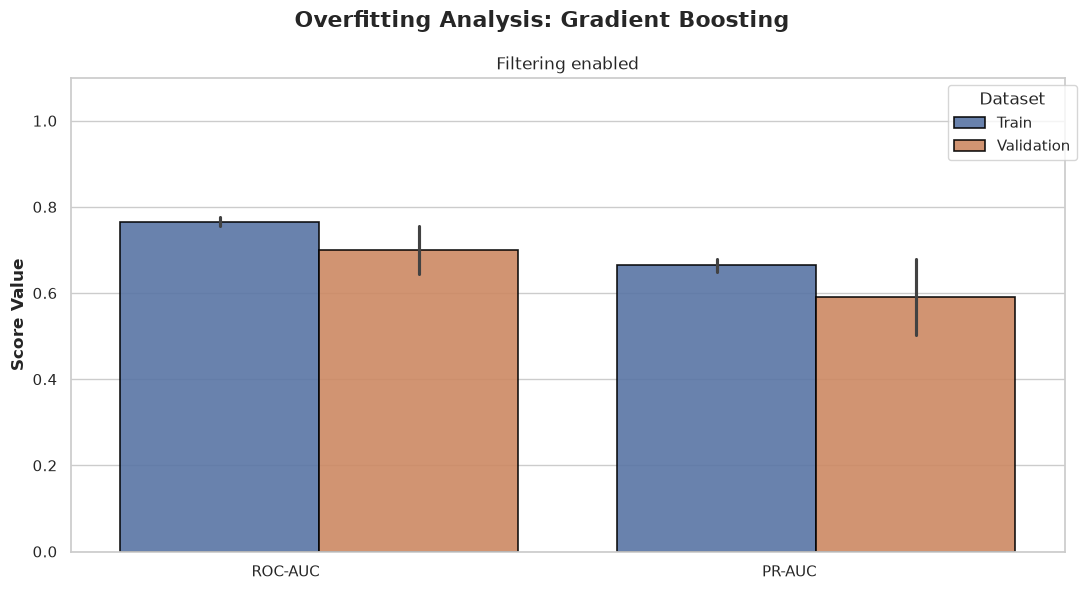

In [42]:
plot_overfitting_bars(df_cv_results=cv_results_GB, 
                    title="Gradient Boosting", 
                    output_dir=results_path, 
                    identifier="GB",
                    filtering=enable_filter)

#### Multi-Layer Perceptron

Define the parameter distributions and set up the pipeline:

In [43]:
# Get the preprocessor
preprocessor_MLP = get_full_preprocessor(X_train_filtered, seed=seed)

# Full pipeline
pipe_MLP = Pipeline(steps=[
    ('preprocessor', preprocessor_MLP),
    ('clf', MLPClassifier(random_state=seed, max_iter=1000, early_stopping=True, validation_fraction=0.1))
])

# Hyperparameters search space
params_dist_MLP = {
    'clf__hidden_layer_sizes': [(50,), (100,), (100, 50), (100, 100), (200, 100)],
    'clf__alpha': loguniform(1e-5, 1e-1),
    'clf__learning_rate_init': loguniform(0.001, 0.01),
    'clf__batch_size': np.logspace(start = 0, stop = 6, base = 2, num = 7).astype(int).tolist(),
    'clf__activation': ['relu', 'tanh', 'logistic'],
    'clf__solver': ['adam', 'sgd']
}

Train and optimize the model:

In [44]:
(
optimized_MLP, 
cv_results_MLP,
fpr_MLP, tpr_MLP,
precs_MLP, recs_MLP
) = optimize_model_random_search(
    pipeline=pipe_MLP, 
    param_distributions=params_dist_MLP, 
    X_train=X_train_filtered, y_train=y_train, 
    X_test=X_test_filtered, y_test=y_test, 
    metrics_dict=scoring_dict, 
    cv=my_cv,
    n_iter=n_trials,
    seed=seed
    )

Starting randomized hyperparameter optimization...
Fitting 5 folds for each of 200 candidates, totalling 1000 fits
Evaluating on the training set...
Evaluating on the test set...


Save the optimized model and check the hyperparameters:

In [45]:
save_model(fitted_pipeline=optimized_MLP, output_dir=results_path, identifier="MLP")


,Hyperparameter,Optimal Value
1,activation,relu
2,alpha,0.000063
3,batch_size,8
4,beta_1,0.9
5,beta_2,0.999
6,early_stopping,True
7,epsilon,0.0
8,hidden_layer_sizes,"(100,)"
9,learning_rate,constant
10,learning_rate_init,0.002261


Check the overfitting:

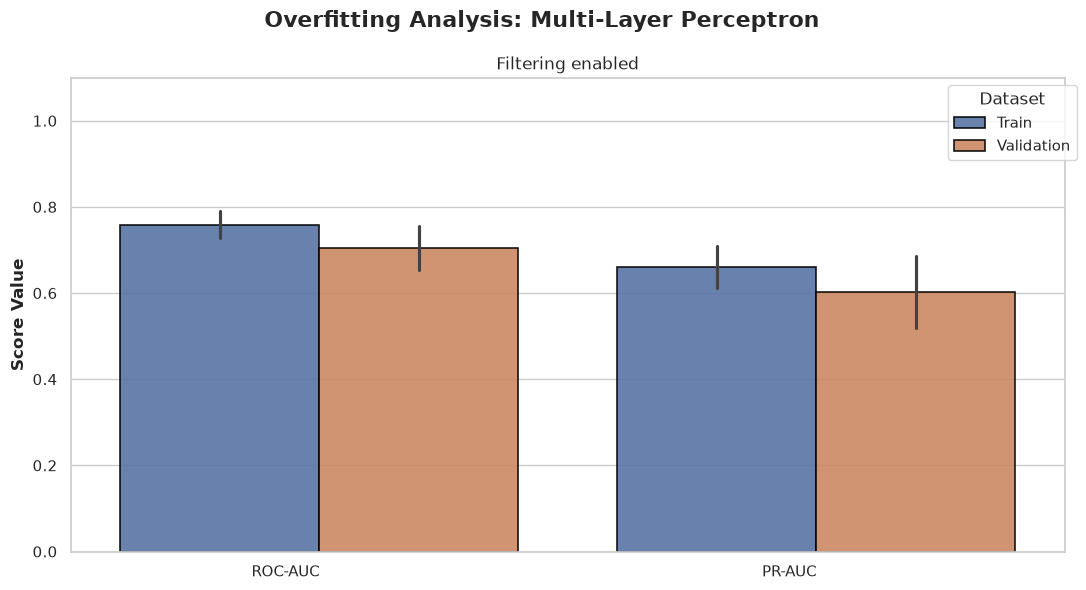

In [46]:
plot_overfitting_bars(df_cv_results=cv_results_MLP, 
                    title="Multi-Layer Perceptron", 
                    output_dir=results_path, 
                    identifier="MLP",
                    filtering=enable_filter)


## Save results

In [47]:
models = ["Elastic Net", "SVM", "Decision Tree", "Random Forest", "Extra Trees", "AdaBoost", "Gradient Boost", "MLP"]

models_dict = {
    "Elastic Net": cv_results_EN,
    "SVM": cv_results_SVM,
    "Decision Tree": cv_results_DT,
    "Random Forest": cv_results_RF,
    "Extra Trees": cv_results_ET,
    "AdaBoost": cv_results_AB,
    "Gradient Boost": cv_results_GB,
    "MLP": cv_results_MLP
}


### Main metrics

In [48]:
results = save_metrics_results(models_dict=models_dict, output_dir=results_path)

results.head()

,Model,Metric,Dataset,Score
0,Elastic Net,ROC-AUC,Train,0.752590
1,Elastic Net,ROC-AUC,Validation,0.672136
2,Elastic Net,ROC-AUC,Train,0.756359
3,Elastic Net,ROC-AUC,Validation,0.641727
4,Elastic Net,ROC-AUC,Train,0.721211


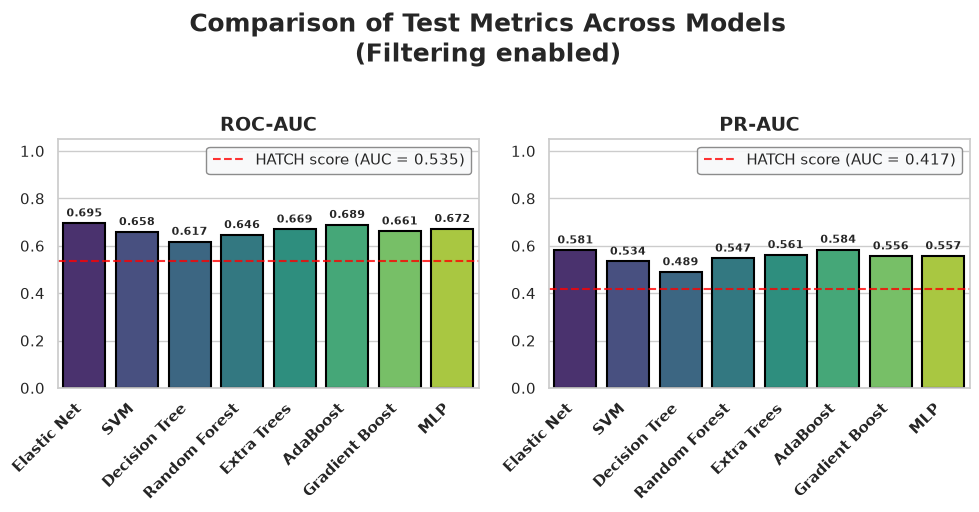

In [49]:
plot_metrics_bars(results, 
                metrics=['ROC-AUC', 'PR-AUC'],
                baselines=[roc_auc_hatch, pr_auc_hatch],
                output_dir=results_path,
                filtering=enable_filter)

### ROC and PR curves

Join the metrics into a csv file:

In [50]:
# Save the false/true positive rates values into a csv
fpr = [fpr_EN, fpr_SVM, fpr_DT, fpr_RF, fpr_ET, fpr_AB, fpr_GB, fpr_MLP]
tpr = [tpr_EN, tpr_SVM, tpr_DT, tpr_RF, tpr_ET, tpr_AB, tpr_GB, tpr_MLP]

roc_results = save_curves_results(models, fpr, tpr, curve_type='roc', 
                                output_dir=results_path)

# Save the precision and recall values for the PR curves into a csv
precs = [precs_EN, precs_SVM, precs_DT, precs_RF, precs_ET, precs_AB, precs_GB, precs_MLP]
recs = [recs_EN, recs_SVM, recs_DT, recs_RF, recs_ET, recs_AB, recs_GB, recs_MLP]

pr_results = save_curves_results(models, recs, precs, curve_type='pr', 
                                output_dir=results_path)


Plot ROC curves:

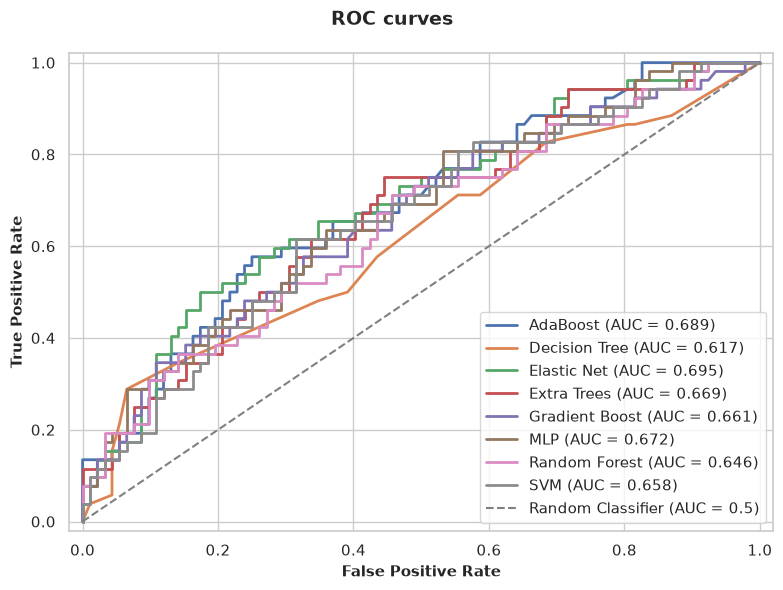

In [53]:
plot_model_curves(roc_results, 
                x_col='False Positive Rate', y_col='True Positive Rate', 
                curve_type='roc', title="ROC curves",
                output_dir=results_path)

Plot PR curves:

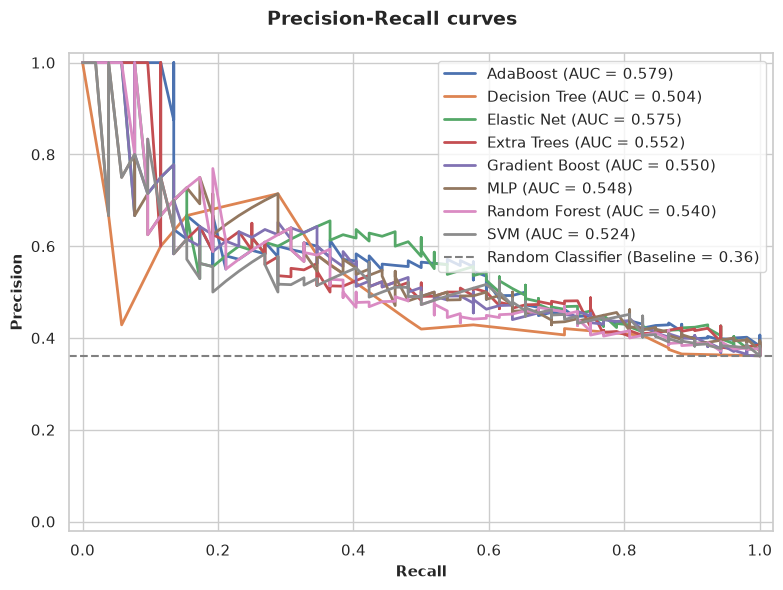

In [54]:
# Use the actual prevalence for the random classifier baseline
test_prevalence = y_test.astype(float).mean()

plot_model_curves(pr_results, 
                x_col='Recall', y_col='Precision', 
                curve_type='pr', title="Precision-Recall curves",
                prevalence=test_prevalence,
                output_dir=results_path)
